In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/Sepsis Project/sepsis_dataset.zip"

In [ ]:
!unzip -q "$zip_path" -d /content/sepsis_data

In [ ]:
import os

data_path = "/content/sepsis_data/content/sepsis_dataset"
print("Total files:", len(os.listdir(data_path)))

Total files: 40336


In [ ]:
!mkdir -p /content/dataset

In [ ]:
!rsync -a /content/sepsis_data/content/sepsis_dataset/ /content/dataset/

In [ ]:
!rm -r /content/sepsis_data

In [ ]:
import os

DATA_PATH = "/content/dataset"
print("Total files:", len(os.listdir(DATA_PATH)))

Total files: 40336


In [ ]:
sample_file = os.path.join(DATA_PATH, files[0])
print(sample_file)

/content/dataset/p107963.psv


In [ ]:
import pandas as pd

df = pd.read_csv(sample_file, sep='|')
df.head()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,1,0
1,91.0,100.0,NaN,143.0,73.0,55.0,20.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,2,0
2,96.0,97.0,NaN,141.0,72.0,49.0,24.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,3,0
3,98.0,96.0,NaN,149.0,78.0,55.0,28.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,4,0
4,98.5,97.0,37.8,124.5,88.5,77.0,25.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,5,0


In [ ]:
df.shape

(57, 41)

In [ ]:
df.columns

Index(['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
       'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
       'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
       'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
       'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel'],
      dtype='object')

In [ ]:
df

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,1,0
1,91.0,100.0,NaN,143.0,73.0,55.0,20.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,2,0
2,96.0,97.0,NaN,141.0,72.0,49.0,24.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,3,0
3,98.0,96.0,NaN,149.0,78.0,55.0,28.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,4,0
4,98.5,97.0,37.8,124.5,88.5,77.0,25.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,5,0
5,94.0,96.0,NaN,153.0,77.0,50.0,23.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,6,0
6,96.0,99.0,NaN,166.0,95.0,70.0,20.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,7,0
7,94.0,94.0,NaN,144.5,73.5,52.5,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,8,0
8,110.0,100.0,37.3,141.0,78.0,53.0,25.0,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,9,0
9,85.0,NaN,NaN,156.0,NaN,67.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,56,0,0,1,-0.32,10,0


In [ ]:
import os
import numpy as np
import pandas as pd

DATA_PATH = "/content/dataset"   # your folder with .psv files

all_rows = []

for file in os.listdir(DATA_PATH):
    if file.endswith(".psv"):
        file_path = os.path.join(DATA_PATH, file)

        try:
            df = pd.read_csv(file_path, sep='|')

            # -------- HR processing --------
            hr = df['HR'].fillna(method='ffill').fillna(method='bfill')

            features = {}

            # Basic stats
            features['HR_last'] = hr.iloc[-1]
            features['HR_mean'] = hr.mean()
            features['HR_std'] = hr.std()
            features['HR_min'] = hr.min()
            features['HR_max'] = hr.max()

            # Trend
            features['HR_trend'] = hr.iloc[-1] - hr.iloc[0]

            # Differences
            diff = hr.diff().fillna(0)
            features['HR_diff_mean'] = diff.mean()
            features['HR_diff_max'] = diff.max()
            features['HR_diff_min'] = diff.min()

            # Recent behavior
            features['HR_recent_mean'] = hr.tail(6).mean()

            # -------- Metadata --------
            features['Patient_ID'] = file.replace('.psv', '')
            features['SepsisLabel'] = df['SepsisLabel'].max()
            features['num_hours'] = len(df)

            all_rows.append(features)

        except:
            continue

# -------- Create DataFrame --------
final_df = pd.DataFrame(all_rows)

# -------- Save dataset --------
final_df.to_csv("/content/hr_features_dataset.csv", index=False)

# -------- Preview --------
print("Shape:", final_df.shape)
print(final_df.head())

Streaming output truncated to the last 5000 lines.
/tmp/ipykernel_1100/3913793750.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hr = df['HR'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_1100/3913793750.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hr = df['HR'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_1100/3913793750.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hr = df['HR'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_1100/3913793750.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hr = df['HR'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_11

Shape: (40336, 13)
   HR_last     HR_mean     HR_std  HR_min  HR_max  HR_trend  HR_diff_mean  \
0     89.0   92.122807   4.976086    84.0   110.0      -2.0     -0.035088   
1    120.0  104.052632  11.035124    89.0   128.0      -2.0     -0.035088   
2     59.5   61.094595   2.266415    59.5    70.0      -0.5     -0.013514   
3    104.0  106.762500   5.535419    99.0   121.0       5.0      0.125000   
4     76.0   75.706897   7.331759    61.0    89.0      14.0      0.241379   

   HR_diff_max  HR_diff_min  HR_recent_mean Patient_ID  SepsisLabel  num_hours  
0         16.0        -25.0       89.000000    p107963            1         57  
1         15.0        -18.0      119.166667    p001668            1         57  
2          7.0         -8.0       62.416667    p006604            0         37  
3         10.5         -9.0      108.000000    p011881            0         40  
4         16.0         -8.0       77.000000    p001743            0         58  


In [ ]:
final_df

,HR_last,HR_mean,HR_std,HR_min,HR_max,HR_trend,HR_diff_mean,HR_diff_max,HR_diff_min,HR_recent_mean,Patient_ID,SepsisLabel,num_hours
0,89.0,92.122807,4.976086,84.0,110.0,-2.0,-0.035088,16.0,-25.0,89.000000,p107963,1,57
1,120.0,104.052632,11.035124,89.0,128.0,-2.0,-0.035088,15.0,-18.0,119.166667,p001668,1,57
2,59.5,61.094595,2.266415,59.5,70.0,-0.5,-0.013514,7.0,-8.0,62.416667,p006604,0,37
3,104.0,106.762500,5.535419,99.0,121.0,5.0,0.125000,10.5,-9.0,108.000000,p011881,0,40
4,76.0,75.706897,7.331759,61.0,89.0,14.0,0.241379,16.0,-8.0,77.000000,p001743,0,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40331,97.0,86.548780,7.217864,73.0,98.0,24.0,0.585366,15.0,-17.0,93.000000,p019418,0,41
40332,57.0,81.357143,10.911099,57.0,103.0,-34.0,-0.693878,22.0,-29.5,74.833333,p119998,0,49
40333,117.0,109.937500,5.825071,99.0,120.0,3.0,0.093750,12.0,-13.0,113.666667,p015733,0,32
40334,90.5,83.905172,4.456866,75.0,97.0,6.5,0.112069,9.0,-11.5,92.250000,p107882,0,58


In [ ]:
final_df.to_csv("hr_features_dataset.csv", index=False)

In [ ]:
import os
import numpy as np
import pandas as pd

DATA_PATH = "/content/dataset"

all_rows = []

for file in os.listdir(DATA_PATH):
    if file.endswith(".psv"):
        file_path = os.path.join(DATA_PATH, file)

        try:
            df = pd.read_csv(file_path, sep='|')

            features = {}

            # ======================
            # HR FEATURES
            # ======================
            hr = df['HR'].ffill().bfill()

            features['HR_last'] = hr.iloc[-1]
            features['HR_mean'] = hr.mean()
            features['HR_std'] = hr.std()
            features['HR_min'] = hr.min()
            features['HR_max'] = hr.max()
            features['HR_trend'] = hr.iloc[-1] - hr.iloc[0]

            diff_hr = hr.diff().fillna(0)
            features['HR_diff_mean'] = diff_hr.mean()
            features['HR_diff_max'] = diff_hr.max()
            features['HR_diff_min'] = diff_hr.min()

            features['HR_recent_mean'] = hr.tail(6).mean()


            # ======================
            # O2Sat FEATURES
            # ======================
            o2 = df['O2Sat'].ffill().bfill()

            features['O2_last'] = o2.iloc[-1]
            features['O2_mean'] = o2.mean()
            features['O2_std'] = o2.std()
            features['O2_min'] = o2.min()
            features['O2_trend'] = o2.iloc[-1] - o2.iloc[0]

            diff_o2 = o2.diff().fillna(0)
            features['O2_diff_min'] = diff_o2.min()

            features['O2_recent_mean'] = o2.tail(6).mean()

            # fraction of time O2Sat < 92
            features['O2_low_frac'] = (o2 < 92).mean()


            # ======================
            # META + TARGET
            # ======================
            features['Patient_ID'] = file.replace('.psv', '')
            features['SepsisLabel'] = df['SepsisLabel'].max()
            features['num_hours'] = len(df)


            all_rows.append(features)

        except:
            continue


# ======================
# FINAL DATAFRAME
# ======================
final_df = pd.DataFrame(all_rows)

# save file
final_df.to_csv("/content/hr_o2_features.csv", index=False)

print("Shape:", final_df.shape)
print(final_df.head())

Shape: (40336, 21)
   HR_last     HR_mean     HR_std  HR_min  HR_max  HR_trend  HR_diff_mean  \
0     89.0   92.122807   4.976086    84.0   110.0      -2.0     -0.035088   
1    120.0  104.052632  11.035124    89.0   128.0      -2.0     -0.035088   
2     59.5   61.094595   2.266415    59.5    70.0      -0.5     -0.013514   
3    104.0  106.762500   5.535419    99.0   121.0       5.0      0.125000   
4     76.0   75.706897   7.331759    61.0    89.0      14.0      0.241379   

   HR_diff_max  HR_diff_min  HR_recent_mean  ...    O2_mean    O2_std  O2_min  \
0         16.0        -25.0       89.000000  ...  97.859649  1.574786    94.0   
1         15.0        -18.0      119.166667  ...  95.394737  3.728195    80.0   
2          7.0         -8.0       62.416667  ...  97.162162  2.366004    92.0   
3         10.5         -9.0      108.000000  ...  93.762500  2.449457    88.0   
4         16.0         -8.0       77.000000  ...  93.965517  1.350315    92.0   

   O2_trend  O2_diff_min  O2_re

In [ ]:
import os
import pandas as pd
import numpy as np

DATA_PATH = "/content/dataset"

rows = []

total_vals = 0
total_missing = 0

for file in os.listdir(DATA_PATH):
    if not file.endswith(".psv"):
        continue

    fp = os.path.join(DATA_PATH, file)
    try:
        df = pd.read_csv(fp, sep='|', usecols=['Temp'])
    except:
        continue

    temp = df['Temp']
    n = len(temp)
    miss = temp.isna().sum()
    frac = miss / n if n > 0 else np.nan

    # ---- pattern analysis ----
    is_na = temp.isna().values

    # missing at start / end
    miss_start = 0
    for v in is_na:
        if v: miss_start += 1
        else: break

    miss_end = 0
    for v in is_na[::-1]:
        if v: miss_end += 1
        else: break

    # longest consecutive missing block
    longest_gap = 0
    curr = 0
    for v in is_na:
        if v:
            curr += 1
            longest_gap = max(longest_gap, curr)
        else:
            curr = 0

    # number of missing segments
    segments = 0
    in_gap = False
    for v in is_na:
        if v and not in_gap:
            segments += 1
            in_gap = True
        elif not v:
            in_gap = False

    rows.append({
        "Patient_ID": file.replace(".psv",""),
        "num_hours": n,
        "temp_missing_count": miss,
        "temp_missing_frac": frac,
        "miss_start": miss_start,
        "miss_end": miss_end,
        "longest_gap": longest_gap,
        "gap_segments": segments
    })

    total_vals += n
    total_missing += miss

# ---- per-patient table ----
miss_df = pd.DataFrame(rows)

# ---- overall stats ----
overall_missing_frac = total_missing / total_vals

print("Overall Temp missing fraction:", overall_missing_frac)
print(miss_df.describe())

# ---- save for inspection ----
miss_df.to_csv("/content/temp_missingness_report.csv", index=False)

Overall Temp missing fraction: 0.6616269705774348
          num_hours  temp_missing_count  temp_missing_frac    miss_start  \
count  40336.000000        40336.000000       40336.000000  40336.000000   
mean      38.482001           25.460730           0.664265      2.855489   
std       22.795923           17.581685           0.224298      4.318027   
min        8.000000            0.000000           0.000000      0.000000   
25%       24.000000           15.000000           0.666667      1.000000   
50%       38.000000           25.000000           0.750000      2.000000   
75%       47.000000           34.000000           0.787879      4.000000   
max      336.000000          279.000000           1.000000    168.000000   

           miss_end   longest_gap  gap_segments  
count  40336.000000  40336.000000  40336.000000  
mean       2.268247      6.024593      8.249405  
std        3.763854      4.959355      5.703641  
min        0.000000      0.000000      0.000000  
25%        0.00

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

DATA_PATH = "/content/dataset"

all_rows = []

def process_file(file_path):
    df = pd.read_csv(file_path, sep='|')

    patient_id = os.path.basename(file_path)

    row = {"patient_id": patient_id}

    # =========================
    # HEART RATE FEATURES
    # =========================
    hr = df['HR']

    row['HR_mean'] = hr.mean()
    row['HR_std'] = hr.std()
    row['HR_min'] = hr.min()
    row['HR_max'] = hr.max()
    row['HR_last'] = hr.iloc[-1]

    # trend (slope)
    if hr.notna().sum() > 1:
        x = np.arange(len(hr))
        mask = hr.notna()
        row['HR_trend'] = np.polyfit(x[mask], hr[mask], 1)[0]
    else:
        row['HR_trend'] = np.nan

    # =========================
    # OXYGEN SATURATION FEATURES
    # =========================
    o2 = df['O2Sat']

    row['O2_mean'] = o2.mean()
    row['O2_std'] = o2.std()
    row['O2_min'] = o2.min()
    row['O2_max'] = o2.max()
    row['O2_last'] = o2.iloc[-1]

    # low oxygen (critical)
    row['O2_below_92_frac'] = (o2 < 92).sum() / len(o2)

    # =========================
    # TEMPERATURE FEATURES
    # =========================
    temp = df['Temp']

    total = len(temp)
    missing = temp.isna().sum()

    # missingness
    row['Temp_missing_frac'] = missing / total

    # valid values
    temp_valid = temp.dropna()

    if len(temp_valid) > 0:
        row['Temp_mean'] = temp_valid.mean()
        row['Temp_std'] = temp_valid.std()
        row['Temp_min'] = temp_valid.min()
        row['Temp_max'] = temp_valid.max()
        row['Temp_last'] = temp_valid.iloc[-1]

        # fever indicator (> 38°C)
        row['Temp_fever_frac'] = (temp_valid > 38).sum() / len(temp_valid)

        # hypothermia (< 36°C)
        row['Temp_low_frac'] = (temp_valid < 36).sum() / len(temp_valid)

        # trend
        if len(temp_valid) > 1:
            x = np.arange(len(temp))
            mask = temp.notna()
            row['Temp_trend'] = np.polyfit(x[mask], temp[mask], 1)[0]
        else:
            row['Temp_trend'] = np.nan
    else:
        # if all missing
        row['Temp_mean'] = np.nan
        row['Temp_std'] = np.nan
        row['Temp_min'] = np.nan
        row['Temp_max'] = np.nan
        row['Temp_last'] = np.nan
        row['Temp_fever_frac'] = np.nan
        row['Temp_low_frac'] = np.nan
        row['Temp_trend'] = np.nan

    # =========================
    # LABEL
    # =========================
    row['SepsisLabel'] = df['SepsisLabel'].max()

    return row


# =========================
# PROCESS ALL FILES
# =========================
files = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.psv')]

for f in tqdm(files):
    try:
        row = process_file(f)
        all_rows.append(row)
    except:
        continue

final_df = pd.DataFrame(all_rows)

print("Final shape:", final_df.shape)
final_df.head()

100%|██████████| 40336/40336 [02:36<00:00, 257.46it/s]


Final shape: (40336, 23)


,patient_id,HR_mean,HR_std,HR_min,HR_max,HR_last,HR_trend,O2_mean,O2_std,O2_min,...,Temp_missing_frac,Temp_mean,Temp_std,Temp_min,Temp_max,Temp_last,Temp_fever_frac,Temp_low_frac,Temp_trend,SepsisLabel
0,p107963.psv,92.625000,5.234399,84.0,110.0,NaN,-0.023793,97.765957,1.644659,94.0,...,0.807018,36.945455,0.347458,36.60,37.80,36.90,0.000000,0.0,-0.020788,1
1,p001668.psv,104.000000,10.660340,89.0,128.0,120.0,-0.072259,95.259615,3.780095,80.0,...,0.789474,37.533333,0.739930,36.33,38.67,36.33,0.333333,0.0,-0.008496,1
2,p006604.psv,61.132353,2.359086,59.5,70.0,59.5,0.123560,97.090909,2.457306,92.0,...,0.729730,35.044000,0.639152,34.22,36.17,36.17,0.000000,0.9,0.071745,0
3,p011881.psv,107.121622,5.564527,99.0,121.0,NaN,0.121622,93.635135,2.445656,88.0,...,0.550000,37.388333,0.657538,36.60,38.89,38.17,0.222222,0.0,0.046419,0
4,p001743.psv,76.722222,6.525470,61.0,89.0,76.0,0.201164,93.888889,1.283666,92.0,...,0.689655,37.077222,0.439489,36.06,37.94,37.11,0.000000,0.0,-0.001440,0


In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

DATA_PATH = "/content/dataset"

all_rows = []

def process_file(file_path):
    df = pd.read_csv(file_path, sep='|')

    patient_id = os.path.basename(file_path)
    row = {"patient_id": patient_id}

    # =========================
    # HEART RATE
    # =========================
    hr = df['HR']
    row['HR_mean'] = hr.mean()
    row['HR_std'] = hr.std()
    row['HR_min'] = hr.min()
    row['HR_max'] = hr.max()
    row['HR_last'] = hr.dropna().iloc[-1] if hr.notna().any() else np.nan

    if hr.notna().sum() > 1:
        x = np.arange(len(hr))
        mask = hr.notna()
        row['HR_trend'] = np.polyfit(x[mask], hr[mask], 1)[0]
    else:
        row['HR_trend'] = np.nan

    # =========================
    # OXYGEN SATURATION
    # =========================
    o2 = df['O2Sat']
    row['O2_mean'] = o2.mean()
    row['O2_std'] = o2.std()
    row['O2_min'] = o2.min()
    row['O2_max'] = o2.max()
    row['O2_last'] = o2.dropna().iloc[-1] if o2.notna().any() else np.nan
    row['O2_below_92_frac'] = (o2 < 92).sum() / len(o2)

    # =========================
    # TEMPERATURE
    # =========================
    temp = df['Temp']
    total = len(temp)
    missing = temp.isna().sum()

    row['Temp_missing_frac'] = missing / total
    temp_valid = temp.dropna()

    if len(temp_valid) > 0:
        row['Temp_mean'] = temp_valid.mean()
        row['Temp_std'] = temp_valid.std()
        row['Temp_min'] = temp_valid.min()
        row['Temp_max'] = temp_valid.max()
        row['Temp_last'] = temp_valid.iloc[-1]
        row['Temp_fever_frac'] = (temp_valid > 38).sum() / len(temp_valid)
        row['Temp_low_frac'] = (temp_valid < 36).sum() / len(temp_valid)

        if len(temp_valid) > 1:
            x = np.arange(len(temp))
            mask = temp.notna()
            row['Temp_trend'] = np.polyfit(x[mask], temp[mask], 1)[0]
        else:
            row['Temp_trend'] = np.nan
    else:
        row.update({
            'Temp_mean': np.nan,
            'Temp_std': np.nan,
            'Temp_min': np.nan,
            'Temp_max': np.nan,
            'Temp_last': np.nan,
            'Temp_fever_frac': np.nan,
            'Temp_low_frac': np.nan,
            'Temp_trend': np.nan
        })

    # =========================
    # BLOOD PRESSURE (NEW)
    # =========================
    sbp = df['SBP']
    dbp = df['DBP']
    map_ = df['MAP']

    # core
    row['SBP_mean'] = sbp.mean()
    row['DBP_mean'] = dbp.mean()
    row['MAP_mean'] = map_.mean()

    # variability
    row['SBP_std'] = sbp.std()
    row['MAP_std'] = map_.std()

    # extremes
    row['SBP_min'] = sbp.min()
    row['MAP_min'] = map_.min()

    # last
    row['MAP_last'] = map_.dropna().iloc[-1] if map_.notna().any() else np.nan

    # thresholds
    row['MAP_low_frac'] = (map_ < 65).sum() / len(map_)
    row['SBP_low_frac'] = (sbp < 90).sum() / len(sbp)

    # derived
    pulse_pressure = sbp - dbp
    row['PulsePressure_mean'] = pulse_pressure.mean()

    shock_index = hr / sbp
    row['ShockIndex_mean'] = shock_index.replace([np.inf, -np.inf], np.nan).mean()

    # trend
    if map_.notna().sum() > 1:
        x = np.arange(len(map_))
        mask = map_.notna()
        row['MAP_trend'] = np.polyfit(x[mask], map_[mask], 1)[0]
    else:
        row['MAP_trend'] = np.nan

    # =========================
    # LABEL
    # =========================
    row['SepsisLabel'] = df['SepsisLabel'].max()

    return row


# =========================
# RUN ON ALL FILES
# =========================
files = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.psv')]

for f in tqdm(files):
    try:
        all_rows.append(process_file(f))
    except:
        continue

final_df = pd.DataFrame(all_rows)

print("Final shape:", final_df.shape)
final_df.head()

100%|██████████| 40336/40336 [03:55<00:00, 171.02it/s]


Final shape: (40336, 36)


,patient_id,HR_mean,HR_std,HR_min,HR_max,HR_last,HR_trend,O2_mean,O2_std,O2_min,...,MAP_std,SBP_min,MAP_min,MAP_last,MAP_low_frac,SBP_low_frac,PulsePressure_mean,ShockIndex_mean,MAP_trend,SepsisLabel
0,p107963.psv,92.625000,5.234399,84.0,110.0,89.0,-0.023793,97.765957,1.644659,94.0,...,7.955257,101.0,62.00,67.00,0.087719,0.000000,75.239583,0.709547,-0.010218,1
1,p001668.psv,104.000000,10.660340,89.0,128.0,120.0,-0.072259,95.259615,3.780095,80.0,...,11.481106,89.0,64.00,84.00,0.035088,0.017544,46.643750,0.912263,0.286082,1
2,p006604.psv,61.132353,2.359086,59.5,70.0,59.5,0.123560,97.090909,2.457306,92.0,...,22.350896,74.0,43.17,107.67,0.189189,0.054054,NaN,0.468439,1.998762,0
3,p011881.psv,107.121622,5.564527,99.0,121.0,104.0,0.121622,93.635135,2.445656,88.0,...,11.649086,118.0,78.00,78.00,0.000000,0.000000,77.770270,0.681594,-0.186107,0
4,p001743.psv,76.722222,6.525470,61.0,89.0,76.0,0.201164,93.888889,1.283666,92.0,...,9.603392,113.0,76.00,113.00,0.000000,0.000000,68.916667,0.568204,0.365757,0


In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

DATA_PATH = "/content/dataset"

# create mapping from patient_id → resp features
resp_features_list = []

for file in tqdm(os.listdir(DATA_PATH)):
    if file.endswith(".psv"):
        file_path = os.path.join(DATA_PATH, file)

        try:
            df = pd.read_csv(file_path, sep='|')
            resp = df['Resp']

            row = {}
            row['patient_id'] = file  # must match existing dataframe

            # features
            row['Resp_mean'] = resp.mean()
            row['Resp_std'] = resp.std()
            row['Resp_max'] = resp.max()
            row['Resp_last'] = resp.dropna().iloc[-1] if resp.notna().any() else np.nan

            valid = resp.dropna()
            row['Resp_high_frac'] = (valid >= 22).sum() / len(valid) if len(valid) > 0 else np.nan

            if resp.notna().sum() > 1:
                x = np.arange(len(resp))
                mask = resp.notna()
                row['Resp_trend'] = np.polyfit(x[mask], resp[mask], 1)[0]
            else:
                row['Resp_trend'] = np.nan

            resp_features_list.append(row)

        except:
            continue

# convert to dataframe
resp_df = pd.DataFrame(resp_features_list)

# =========================
# MERGE WITH EXISTING DATA
# =========================
final_df = final_df.merge(resp_df, on="patient_id", how="left")

print("Updated shape:", final_df.shape)
final_df.head()

100%|██████████| 40336/40336 [02:05<00:00, 320.15it/s]


Updated shape: (40336, 42)


,patient_id,HR_mean,HR_std,HR_min,HR_max,HR_last,HR_trend,O2_mean,O2_std,O2_min,...,PulsePressure_mean,ShockIndex_mean,MAP_trend,SepsisLabel,Resp_mean,Resp_std,Resp_max,Resp_last,Resp_high_frac,Resp_trend
0,p107963.psv,92.625000,5.234399,84.0,110.0,89.0,-0.023793,97.765957,1.644659,94.0,...,75.239583,0.709547,-0.010218,1,19.397727,4.386262,28.0,23.0,0.340909,-0.172989
1,p001668.psv,104.000000,10.660340,89.0,128.0,120.0,-0.072259,95.259615,3.780095,80.0,...,46.643750,0.912263,0.286082,1,21.456731,4.268478,29.0,28.0,0.557692,0.005564
2,p006604.psv,61.132353,2.359086,59.5,70.0,59.5,0.123560,97.090909,2.457306,92.0,...,NaN,0.468439,1.998762,0,16.470588,4.253236,25.0,14.5,0.176471,0.016024
3,p011881.psv,107.121622,5.564527,99.0,121.0,104.0,0.121622,93.635135,2.445656,88.0,...,77.770270,0.681594,-0.186107,0,18.810811,2.688327,28.0,20.0,0.135135,0.043349
4,p001743.psv,76.722222,6.525470,61.0,89.0,76.0,0.201164,93.888889,1.283666,92.0,...,68.916667,0.568204,0.365757,0,20.740741,5.205894,35.0,26.0,0.444444,0.016791


In [ ]:
import os
import pandas as pd
import numpy as np

DATA_PATH = "/content/dataset"

cols = ['EtCO2', 'BaseExcess', 'HCO3']

rows = []

total_counts = {c: 0 for c in cols}
missing_counts = {c: 0 for c in cols}

for file in os.listdir(DATA_PATH):
    if not file.endswith(".psv"):
        continue

    fp = os.path.join(DATA_PATH, file)
    try:
        df = pd.read_csv(fp, sep='|', usecols=cols)
    except:
        continue

    row = {"patient_id": file.replace(".psv",""), "num_hours": len(df)}

    for c in cols:
        s = df[c]
        n = len(s)
        miss = s.isna().sum()

        frac = miss / n if n > 0 else np.nan
        row[f"{c}_missing_frac"] = frac

        total_counts[c] += n
        missing_counts[c] += miss

    rows.append(row)

# per-patient dataframe
miss_df = pd.DataFrame(rows)

# overall missing fractions
overall = {c: (missing_counts[c] / total_counts[c]) for c in cols}

print("=== Overall Missing Fractions ===")
for c, v in overall.items():
    print(f"{c}: {v:.4f}")

print("\n=== Per-patient summary ===")
print(miss_df[[f"{c}_missing_frac" for c in cols]].describe())

# save detailed report
miss_df.to_csv("/content/etco2_baseexcess_hco3_missingness.csv", index=False)
print("\nSaved detailed report to /content/etco2_baseexcess_hco3_missingness.csv")

=== Overall Missing Fractions ===
EtCO2: 0.9629
BaseExcess: 0.9458
HCO3: 0.9581

=== Per-patient summary ===
       EtCO2_missing_frac  BaseExcess_missing_frac  HCO3_missing_frac
count        40336.000000             40336.000000       40336.000000
mean             0.971115                 0.947102           0.958071
std              0.128969                 0.104089           0.055523
min              0.000000                 0.000000           0.285714
25%              1.000000                 0.937500           0.930233
50%              1.000000                 1.000000           0.981481
75%              1.000000                 1.000000           1.000000
max              1.000000                 1.000000           1.000000

Saved detailed report to /content/etco2_baseexcess_hco3_missingness.csv


In [ ]:
import os
import pandas as pd
import numpy as np

DATA_PATH = "/content/dataset"

cols = ['FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
        'Alkalinephos', 'Calcium', 'Chloride']

rows = []

total_counts = {c: 0 for c in cols}
missing_counts = {c: 0 for c in cols}

for file in os.listdir(DATA_PATH):
    if not file.endswith(".psv"):
        continue

    fp = os.path.join(DATA_PATH, file)

    try:
        df = pd.read_csv(fp, sep='|', usecols=cols)
    except:
        continue

    row = {
        "patient_id": file.replace(".psv", ""),
        "num_hours": len(df)
    }

    for c in cols:
        s = df[c]
        n = len(s)
        miss = s.isna().sum()

        frac = miss / n if n > 0 else np.nan
        row[f"{c}_missing_frac"] = frac

        total_counts[c] += n
        missing_counts[c] += miss

    rows.append(row)

# create dataframe
miss_df = pd.DataFrame(rows)

# overall missing %
overall = {c: (missing_counts[c] / total_counts[c]) for c in cols}

print("=== Overall Missing Fractions ===")
for c, v in overall.items():
    print(f"{c}: {v:.4f}")

print("\n=== Per-patient summary ===")
print(miss_df[[f"{c}_missing_frac" for c in cols]].describe())

# save report
miss_df.to_csv("/content/lab_missingness_report.csv", index=False)

print("\nSaved report to: /content/lab_missingness_report.csv")

=== Overall Missing Fractions ===
FiO2: 0.9167
pH: 0.9307
PaCO2: 0.9444
SaO2: 0.9655
AST: 0.9838
BUN: 0.9313
Alkalinephos: 0.9839
Calcium: 0.9412
Chloride: 0.9546

=== Per-patient summary ===
       FiO2_missing_frac  pH_missing_frac  PaCO2_missing_frac  \
count       40336.000000     40336.000000        40336.000000   
mean            0.923597         0.932229            0.946252   
std             0.121896         0.112269            0.088529   
min             0.000000         0.000000            0.083333   
25%             0.881356         0.902439            0.921053   
50%             1.000000         1.000000            1.000000   
75%             1.000000         1.000000            1.000000   
max             1.000000         1.000000            1.000000   

       SaO2_missing_frac  AST_missing_frac  BUN_missing_frac  \
count       40336.000000      40336.000000      40336.000000   
mean            0.965709          0.983484          0.930335   
std             0.075216      

In [ ]:
import os
import pandas as pd
import numpy as np

DATA_PATH = "/content/dataset"

cols = ['Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate',
        'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total',
        'TroponinI', 'Hct', 'Hgb', 'PTT']

rows = []

total_counts = {c: 0 for c in cols}
missing_counts = {c: 0 for c in cols}

for file in os.listdir(DATA_PATH):
    if not file.endswith(".psv"):
        continue

    fp = os.path.join(DATA_PATH, file)

    try:
        df = pd.read_csv(fp, sep='|', usecols=cols)
    except:
        continue

    row = {
        "patient_id": file.replace(".psv", ""),
        "num_hours": len(df)
    }

    for c in cols:
        s = df[c]
        n = len(s)
        miss = s.isna().sum()

        frac = miss / n if n > 0 else np.nan
        row[f"{c}_missing_frac"] = frac

        total_counts[c] += n
        missing_counts[c] += miss

    rows.append(row)

# create dataframe
miss_df = pd.DataFrame(rows)

# overall missing %
overall = {c: (missing_counts[c] / total_counts[c]) for c in cols}

print("=== Overall Missing Fractions ===")
for c, v in overall.items():
    print(f"{c}: {v:.4f}")

print("\n=== Per-patient summary ===")
print(miss_df[[f"{c}_missing_frac" for c in cols]].describe())

# save report
miss_df.to_csv("/content/lab2_missingness_report.csv", index=False)

print("\nSaved report to: /content/lab2_missingness_report.csv")

=== Overall Missing Fractions ===
Creatinine: 0.9390
Bilirubin_direct: 0.9981
Glucose: 0.8289
Lactate: 0.9733
Magnesium: 0.9369
Phosphate: 0.9599
Potassium: 0.9069
Bilirubin_total: 0.9851
TroponinI: 0.9905
Hct: 0.9115
Hgb: 0.9262
PTT: 0.9706

=== Per-patient summary ===
       Creatinine_missing_frac  Bilirubin_direct_missing_frac  \
count             40336.000000                   40336.000000   
mean                  0.938179                       0.998108   
std                   0.034561                       0.010827   
min                   0.550000                       0.744681   
25%                   0.923077                       1.000000   
50%                   0.945455                       1.000000   
75%                   0.957447                       1.000000   
max                   1.000000                       1.000000   

       Glucose_missing_frac  Lactate_missing_frac  Magnesium_missing_frac  \
count          40336.000000          40336.000000            40336

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

DATA_PATH = "/content/dataset"

lab_rows = []

for file in tqdm(os.listdir(DATA_PATH)):
    if not file.endswith(".psv"):
        continue

    path = os.path.join(DATA_PATH, file)

    try:
        df = pd.read_csv(path, sep='|', usecols=['Glucose', 'Creatinine'])

        row = {}
        row['patient_id'] = file  # must match existing final_df

        # ---------- Glucose ----------
        g = df['Glucose']
        valid_g = g.dropna()

        row['Glucose_mean'] = valid_g.mean()
        row['Glucose_last'] = valid_g.iloc[-1] if len(valid_g) > 0 else np.nan
        row['Glucose_missing_frac'] = g.isna().mean()

        # ---------- Creatinine ----------
        c = df['Creatinine']
        valid_c = c.dropna()

        row['Creatinine_mean'] = valid_c.mean()
        row['Creatinine_last'] = valid_c.iloc[-1] if len(valid_c) > 0 else np.nan
        row['Creatinine_missing_frac'] = c.isna().mean()

        lab_rows.append(row)

    except:
        continue

# convert to dataframe
lab_df = pd.DataFrame(lab_rows)

# 🔗 merge into your existing dataframe
final_df = final_df.merge(lab_df, on="patient_id", how="left")

print("Updated shape:", final_df.shape)
final_df.head()

100%|██████████| 40336/40336 [01:10<00:00, 575.44it/s]


Updated shape: (40336, 48)


,patient_id,HR_mean,HR_std,HR_min,HR_max,HR_last,HR_trend,O2_mean,O2_std,O2_min,...,Resp_max,Resp_last,Resp_high_frac,Resp_trend,Glucose_mean,Glucose_last,Glucose_missing_frac,Creatinine_mean,Creatinine_last,Creatinine_missing_frac
0,p107963.psv,92.625000,5.234399,84.0,110.0,89.0,-0.023793,97.765957,1.644659,94.0,...,28.0,23.0,0.340909,-0.172989,184.600000,77.0,0.736842,0.693333,0.74,0.947368
1,p001668.psv,104.000000,10.660340,89.0,128.0,120.0,-0.072259,95.259615,3.780095,80.0,...,29.0,28.0,0.557692,0.005564,163.600000,143.0,0.912281,0.533333,0.60,0.947368
2,p006604.psv,61.132353,2.359086,59.5,70.0,59.5,0.123560,97.090909,2.457306,92.0,...,25.0,14.5,0.176471,0.016024,90.000000,139.0,0.945946,3.450000,3.40,0.945946
3,p011881.psv,107.121622,5.564527,99.0,121.0,104.0,0.121622,93.635135,2.445656,88.0,...,28.0,20.0,0.135135,0.043349,179.785714,177.0,0.650000,0.833333,0.80,0.925000
4,p001743.psv,76.722222,6.525470,61.0,89.0,76.0,0.201164,93.888889,1.283666,92.0,...,35.0,26.0,0.444444,0.016791,112.250000,91.0,0.931034,0.540000,0.40,0.913793


In [ ]:
final_df = final_df.drop(columns=['Creatinine_mean'])

In [ ]:
final_df

,patient_id,HR_mean,HR_std,HR_min,HR_max,HR_last,HR_trend,O2_mean,O2_std,O2_min,...,Resp_std,Resp_max,Resp_last,Resp_high_frac,Resp_trend,Glucose_mean,Glucose_last,Glucose_missing_frac,Creatinine_last,Creatinine_missing_frac
0,p107963.psv,92.625000,5.234399,84.0,110.0,89.0,-0.023793,97.765957,1.644659,94.0,...,4.386262,28.0,23.0,0.340909,-0.172989,184.600000,77.0,0.736842,0.74,0.947368
1,p001668.psv,104.000000,10.660340,89.0,128.0,120.0,-0.072259,95.259615,3.780095,80.0,...,4.268478,29.0,28.0,0.557692,0.005564,163.600000,143.0,0.912281,0.60,0.947368
2,p006604.psv,61.132353,2.359086,59.5,70.0,59.5,0.123560,97.090909,2.457306,92.0,...,4.253236,25.0,14.5,0.176471,0.016024,90.000000,139.0,0.945946,3.40,0.945946
3,p011881.psv,107.121622,5.564527,99.0,121.0,104.0,0.121622,93.635135,2.445656,88.0,...,2.688327,28.0,20.0,0.135135,0.043349,179.785714,177.0,0.650000,0.80,0.925000
4,p001743.psv,76.722222,6.525470,61.0,89.0,76.0,0.201164,93.888889,1.283666,92.0,...,5.205894,35.0,26.0,0.444444,0.016791,112.250000,91.0,0.931034,0.40,0.913793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40331,p019418.psv,86.887500,6.972002,73.0,98.0,97.0,0.220310,96.974359,1.956597,93.0,...,4.020759,34.0,19.0,0.575000,0.014587,163.500000,176.0,0.853659,0.90,0.975610
40332,p119998.psv,80.202381,9.620899,57.0,103.0,57.0,-0.340304,96.255814,3.875092,88.0,...,2.110227,26.0,22.0,0.342105,0.071950,87.000000,83.0,0.959184,8.77,0.959184
40333,p015733.psv,109.566667,5.817236,99.0,120.0,117.0,-0.100334,94.466667,2.800657,88.0,...,4.710328,34.0,26.0,0.793103,-0.223645,98.000000,98.0,0.968750,0.80,0.968750
40334,p107882.psv,84.009804,4.509424,75.0,97.0,90.5,0.036055,96.479592,1.680027,94.0,...,3.395459,29.0,20.0,0.229167,-0.015724,131.350000,128.0,0.827586,3.86,0.965517


In [ ]:
import os
import pandas as pd
from tqdm import tqdm

DATA_PATH = "/content/dataset"

cols = [
    'WBC', 'Fibrinogen', 'Platelets',
    'Age', 'Gender', 'Unit1', 'Unit2',
    'HospAdmTime', 'ICULOS'
]

missing_counts = {c: 0 for c in cols}
total_counts = {c: 0 for c in cols}

for file in tqdm(os.listdir(DATA_PATH)):
    if not file.endswith(".psv"):
        continue

    path = os.path.join(DATA_PATH, file)

    try:
        df = pd.read_csv(path, sep='|', usecols=cols)

        for c in cols:
            total_counts[c] += len(df)
            missing_counts[c] += df[c].isna().sum()

    except:
        continue

print("=== Missing Percentage ===")
for c in cols:
    missing_frac = missing_counts[c] / total_counts[c]
    print(f"{c}: {missing_frac:.4f}")

100%|██████████| 40336/40336 [01:40<00:00, 403.06it/s]

=== Missing Percentage ===
WBC: 0.9359
Fibrinogen: 0.9934
Platelets: 0.9406
Age: 0.0000
Gender: 0.0000
Unit1: 0.3943
Unit2: 0.3943
HospAdmTime: 0.0000
ICULOS: 0.0000


In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

DATA_PATH = "/content/dataset"

extra_rows = []

for file in tqdm(os.listdir(DATA_PATH)):
    if file.endswith(".psv"):
        file_path = os.path.join(DATA_PATH, file)

        try:
            df = pd.read_csv(file_path, sep='|')

            row = {}
            row['patient_id'] = file   # must match your existing final_df

            # =========================
            # WBC
            # =========================
            wbc = df['WBC']
            row['WBC_last'] = wbc.dropna().iloc[-1] if wbc.notna().any() else np.nan
            row['WBC_measured'] = 1 if wbc.notna().any() else 0

            valid_wbc = wbc.dropna()
            row['WBC_abnormal'] = ((valid_wbc > 12) | (valid_wbc < 4)).sum() / len(valid_wbc) if len(valid_wbc) > 0 else np.nan

            # =========================
            # Platelets
            # =========================
            plt = df['Platelets']
            row['Platelets_last'] = plt.dropna().iloc[-1] if plt.notna().any() else np.nan
            row['Platelets_measured'] = 1 if plt.notna().any() else 0

            valid_plt = plt.dropna()
            row['Platelets_low_frac'] = (valid_plt < 150).sum() / len(valid_plt) if len(valid_plt) > 0 else np.nan

            # =========================
            # Fibrinogen
            # =========================
            fib = df['Fibrinogen']
            row['Fibrinogen_last'] = fib.dropna().iloc[-1] if fib.notna().any() else np.nan
            row['Fibrinogen_measured'] = 1 if fib.notna().any() else 0

            # =========================
            # Age + Group
            # =========================
            age = df['Age'].iloc[0]
            row['Age'] = age

            if age < 40:
                row['Age_group'] = 0
            elif age < 65:
                row['Age_group'] = 1
            else:
                row['Age_group'] = 2

            # =========================
            # Gender
            # =========================
            row['Gender'] = df['Gender'].iloc[0]

            # =========================
            # Unit
            # =========================
            row['Unit1'] = df['Unit1'].iloc[0]
            row['Unit2'] = df['Unit2'].iloc[0]

            # =========================
            # ICULOS
            # =========================
            iculos = df['ICULOS']
            last_iculos = iculos.iloc[-1]

            row['ICULOS_last'] = last_iculos

            if last_iculos < 24:
                row['ICULOS_bucket'] = 0
            elif last_iculos < 72:
                row['ICULOS_bucket'] = 1
            else:
                row['ICULOS_bucket'] = 2

            extra_rows.append(row)

        except:
            continue


# convert to dataframe
extra_df = pd.DataFrame(extra_rows)

# =========================
# MERGE INTO EXISTING DATA
# =========================
final_df = final_df.merge(extra_df, on="patient_id", how="left")

print("Updated shape:", final_df.shape)
final_df.head()

100%|██████████| 40336/40336 [02:31<00:00, 266.92it/s]


Updated shape: (40336, 62)


,patient_id,HR_mean,HR_std,HR_min,HR_max,HR_last,HR_trend,O2_mean,O2_std,O2_min,...,Platelets_low_frac,Fibrinogen_last,Fibrinogen_measured,Age,Age_group,Gender,Unit1,Unit2,ICULOS_last,ICULOS_bucket
0,p107963.psv,92.625000,5.234399,84.0,110.0,89.0,-0.023793,97.765957,1.644659,94.0,...,0.00,NaN,0,56.00,1,0,0.0,1.0,57,1
1,p001668.psv,104.000000,10.660340,89.0,128.0,120.0,-0.072259,95.259615,3.780095,80.0,...,0.00,NaN,0,48.55,1,1,NaN,NaN,57,1
2,p006604.psv,61.132353,2.359086,59.5,70.0,59.5,0.123560,97.090909,2.457306,92.0,...,0.00,NaN,0,67.94,2,0,1.0,0.0,37,1
3,p011881.psv,107.121622,5.564527,99.0,121.0,104.0,0.121622,93.635135,2.445656,88.0,...,1.00,171.0,1,54.59,1,1,NaN,NaN,40,1
4,p001743.psv,76.722222,6.525470,61.0,89.0,76.0,0.201164,93.888889,1.283666,92.0,...,0.75,172.0,1,64.14,1,0,NaN,NaN,58,1


In [ ]:
final_df.to_csv("/content/final_dataset1.csv", index=False)

In [ ]:
from google.colab import drive
import pandas as pd

# mount drive
drive.mount('/content/drive')

# path to your file (change name if needed)
file_path = "/content/drive/MyDrive/final_dataset1.csv"

# load dataset
df = pd.read_csv(file_path)

# check
print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(40336, 62)


,patient_id,HR_mean,HR_std,HR_min,HR_max,HR_last,HR_trend,O2_mean,O2_std,O2_min,...,Platelets_low_frac,Fibrinogen_last,Fibrinogen_measured,Age,Age_group,Gender,Unit1,Unit2,ICULOS_last,ICULOS_bucket
0,p107963.psv,92.625000,5.234399,84.0,110.0,89.0,-0.023793,97.765957,1.644659,94.0,...,0.00,NaN,0,56.00,1,0,0.0,1.0,57,1
1,p001668.psv,104.000000,10.660340,89.0,128.0,120.0,-0.072259,95.259615,3.780095,80.0,...,0.00,NaN,0,48.55,1,1,NaN,NaN,57,1
2,p006604.psv,61.132353,2.359086,59.5,70.0,59.5,0.123560,97.090909,2.457306,92.0,...,0.00,NaN,0,67.94,2,0,1.0,0.0,37,1
3,p011881.psv,107.121622,5.564527,99.0,121.0,104.0,0.121622,93.635135,2.445656,88.0,...,1.00,171.0,1,54.59,1,1,NaN,NaN,40,1
4,p001743.psv,76.722222,6.525470,61.0,89.0,76.0,0.201164,93.888889,1.283666,92.0,...,0.75,172.0,1,64.14,1,0,NaN,NaN,58,1


In [ ]:
df.columns

Index(['patient_id', 'HR_mean', 'HR_std', 'HR_min', 'HR_max', 'HR_last',
       'HR_trend', 'O2_mean', 'O2_std', 'O2_min', 'O2_max', 'O2_last',
       'O2_below_92_frac', 'Temp_missing_frac', 'Temp_mean', 'Temp_std',
       'Temp_min', 'Temp_max', 'Temp_last', 'Temp_fever_frac', 'Temp_low_frac',
       'Temp_trend', 'SBP_mean', 'DBP_mean', 'MAP_mean', 'SBP_std', 'MAP_std',
       'SBP_min', 'MAP_min', 'MAP_last', 'MAP_low_frac', 'SBP_low_frac',
       'PulsePressure_mean', 'ShockIndex_mean', 'MAP_trend', 'SepsisLabel',
       'Resp_mean', 'Resp_std', 'Resp_max', 'Resp_last', 'Resp_high_frac',
       'Resp_trend', 'Glucose_mean', 'Glucose_last', 'Glucose_missing_frac',
       'Creatinine_last', 'Creatinine_missing_frac', 'WBC_last',
       'WBC_measured', 'WBC_abnormal', 'Platelets_last', 'Platelets_measured',
       'Platelets_low_frac', 'Fibrinogen_last', 'Fibrinogen_measured', 'Age',
       'Age_group', 'Gender', 'Unit1', 'Unit2', 'ICULOS_last',
       'ICULOS_bucket'],
      dtype='

In [ ]:
cols = ['patient_id', 'HR_mean', 'HR_std', 'HR_min', 'HR_max', 'HR_last', 'HR_trend']

# count of missing values
missing_count = df[cols].isna().sum()

# percentage of missing values
missing_percent = (df[cols].isna().mean() * 100)

# combine in one table
missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_%': missing_percent
})

print(missing_df)

            Missing_Count  Missing_%
patient_id              0   0.000000
HR_mean                 5   0.012396
HR_std                 17   0.042146
HR_min                  5   0.012396
HR_max                  5   0.012396
HR_last                 5   0.012396
HR_trend               17   0.042146


In [ ]:
cols = ['HR_mean', 'HR_std', 'HR_min', 'HR_max', 'HR_last', 'HR_trend']

for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2179/4076165035.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
 cols = ['O2_mean', 'O2_std', 'O2_min', 'O2_max', 'O2_last', 'O2_below_92_frac']

# count
missing_count = df[cols].isna().sum()

# percentage
missing_percent = df[cols].isna().mean() * 100

# combine
missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_%': missing_percent
})

print(missing_df)

                  Missing_Count  Missing_%
O2_mean                      18   0.044625
O2_std                       40   0.099167
O2_min                       18   0.044625
O2_max                       18   0.044625
O2_last                      18   0.044625
O2_below_92_frac              0   0.000000


In [ ]:
cols = ['O2_mean', 'O2_std', 'O2_min', 'O2_max', 'O2_last']

for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2179/353112982.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
cols = [
    'Temp_missing_frac', 'Temp_mean', 'Temp_std',
    'Temp_min', 'Temp_max', 'Temp_last',
    'Temp_fever_frac', 'Temp_low_frac', 'Temp_trend'
]

missing_count = df[cols].isna().sum()
missing_percent = df[cols].isna().mean() * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_%': missing_percent
})

print(missing_df)

                   Missing_Count  Missing_%
Temp_missing_frac              0   0.000000
Temp_mean                    284   0.704086
Temp_std                     753   1.866819
Temp_min                     284   0.704086
Temp_max                     284   0.704086
Temp_last                    284   0.704086
Temp_fever_frac              284   0.704086
Temp_low_frac                284   0.704086
Temp_trend                   753   1.866819


In [ ]:
cols_median = [
    'Temp_mean', 'Temp_std',
    'Temp_min', 'Temp_max', 'Temp_last',
    'Temp_trend'
]

for col in cols_median:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2179/1332381965.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df['Temp_fever_frac'].fillna(0, inplace=True)
df['Temp_low_frac'].fillna(0, inplace=True)

/tmp/ipykernel_2179/1196419675.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Temp_fever_frac'].fillna(0, inplace=True)
/tmp/ipykernel_2179/1196419675.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
cols = [
    'SBP_mean', 'DBP_mean', 'MAP_mean',
    'SBP_std', 'MAP_std',
    'SBP_min', 'MAP_min', 'MAP_last',
    'MAP_low_frac', 'SBP_low_frac',
    'PulsePressure_mean', 'ShockIndex_mean',
    'MAP_trend'
]

missing_count = df[cols].isna().sum()
missing_percent = df[cols].isna().mean() * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_%': missing_percent
})

print(missing_df)

                    Missing_Count  Missing_%
SBP_mean                      282   0.699127
DBP_mean                     7411  18.373165
MAP_mean                      104   0.257834
SBP_std                       356   0.882586
MAP_std                       230   0.570210
SBP_min                       282   0.699127
MAP_min                       104   0.257834
MAP_last                      104   0.257834
MAP_low_frac                    0   0.000000
SBP_low_frac                    0   0.000000
PulsePressure_mean           7411  18.373165
ShockIndex_mean               285   0.706565
MAP_trend                     230   0.570210


In [ ]:
cols_median = [
    'SBP_mean', 'MAP_mean',
    'SBP_std', 'MAP_std',
    'SBP_min', 'MAP_min', 'MAP_last',
    'MAP_trend', 'ShockIndex_mean'
]

for col in cols_median:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2179/1467875955.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df['DBP_mean'].fillna(df['DBP_mean'].median(), inplace=True)

/tmp/ipykernel_2179/1859374120.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DBP_mean'].fillna(df['DBP_mean'].median(), inplace=True)


In [ ]:
# fill missing with median
df['PulsePressure_mean'].fillna(df['PulsePressure_mean'].median(), inplace=True)

/tmp/ipykernel_2179/532823107.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PulsePressure_mean'].fillna(df['PulsePressure_mean'].median(), inplace=True)


In [ ]:
cols = [
    'Resp_mean', 'Resp_std', 'Resp_max',
    'Resp_last', 'Resp_high_frac', 'Resp_trend'
]

missing_count = df[cols].isna().sum()
missing_percent = df[cols].isna().mean() * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_%': missing_percent
})

print(missing_df)

                Missing_Count  Missing_%
Resp_mean                  71   0.176021
Resp_std                  136   0.337168
Resp_max                   71   0.176021
Resp_last                  71   0.176021
Resp_high_frac             71   0.176021
Resp_trend                136   0.337168


In [ ]:
cols_median = [
    'Resp_mean', 'Resp_std',
    'Resp_max', 'Resp_last',
    'Resp_trend'
]

for col in cols_median:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2179/2926937736.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df['Resp_high_frac'].fillna(0, inplace=True)

/tmp/ipykernel_2179/2717015165.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Resp_high_frac'].fillna(0, inplace=True)


In [ ]:
cols = [
    'Glucose_mean', 'Glucose_last', 'Glucose_missing_frac',
    'Creatinine_last', 'Creatinine_missing_frac'
]

missing_count = df[cols].isna().sum()
missing_percent = df[cols].isna().mean() * 100

print(pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_%': missing_percent
}))

                         Missing_Count  Missing_%
Glucose_mean                      1580   3.917096
Glucose_last                      1580   3.917096
Glucose_missing_frac                 0   0.000000
Creatinine_last                   2049   5.079829
Creatinine_missing_frac              0   0.000000


In [ ]:
df['Glucose_mean'].fillna(df['Glucose_mean'].median(), inplace=True)
df['Glucose_last'].fillna(df['Glucose_last'].median(), inplace=True)

df['Creatinine_last'].fillna(df['Creatinine_last'].median(), inplace=True)

/tmp/ipykernel_2179/3943503356.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Glucose_mean'].fillna(df['Glucose_mean'].median(), inplace=True)
/tmp/ipykernel_2179/3943503356.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [ ]:
cols = [
    'WBC_last', 'WBC_measured', 'WBC_abnormal',
    'Platelets_last', 'Platelets_measured',
    'Platelets_low_frac',
    'Fibrinogen_last', 'Fibrinogen_measured'
]

missing_count = df[cols].isna().sum()
missing_percent = df[cols].isna().mean() * 100

print(pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_%': missing_percent
}))

                     Missing_Count  Missing_%
WBC_last                      2625   6.507834
WBC_measured                     0   0.000000
WBC_abnormal                  2625   6.507834
Platelets_last                2577   6.388834
Platelets_measured               0   0.000000
Platelets_low_frac            2577   6.388834
Fibrinogen_last              35821  88.806525
Fibrinogen_measured              0   0.000000


In [ ]:
df['WBC_last'].fillna(df['WBC_last'].median(), inplace=True)
df['WBC_abnormal'].fillna(0, inplace=True)

df['Platelets_last'].fillna(df['Platelets_last'].median(), inplace=True)
df['Platelets_low_frac'].fillna(0, inplace=True)

/tmp/ipykernel_2179/3772699765.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['WBC_last'].fillna(df['WBC_last'].median(), inplace=True)
/tmp/ipykernel_2179/3772699765.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [ ]:
df.drop(columns=['Fibrinogen_last'], inplace=True)

In [ ]:
cols = [
    'Age', 'Age_group', 'Gender',
    'Unit1', 'Unit2',
    'ICULOS_last', 'ICULOS_bucket'
]

missing_count = df[cols].isna().sum()
missing_percent = df[cols].isna().mean() * 100

print(pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_%': missing_percent
}))

               Missing_Count  Missing_%
Age                        0   0.000000
Age_group                  0   0.000000
Gender                     0   0.000000
Unit1                  15617  38.717275
Unit2                  15617  38.717275
ICULOS_last                0   0.000000
ICULOS_bucket              0   0.000000


In [ ]:
df['Unit1'].fillna(0, inplace=True)
df['Unit2'].fillna(0, inplace=True)

/tmp/ipykernel_2179/443212954.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Unit1'].fillna(0, inplace=True)
/tmp/ipykernel_2179/443212954.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.metho

In [ ]:
df.to_csv("/content/final_cleaned_dataset.csv", index=False)

In [ ]:
from google.colab import drive
import pandas as pd

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Path to your saved file
file_path = "/content/drive/MyDrive/final_cleaned_dataset.csv"

# Step 3: Load dataset
df = pd.read_csv(file_path)

# Step 4: Verify
print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (40336, 61)


,patient_id,HR_mean,HR_std,HR_min,HR_max,HR_last,HR_trend,O2_mean,O2_std,O2_min,...,Platelets_measured,Platelets_low_frac,Fibrinogen_measured,Age,Age_group,Gender,Unit1,Unit2,ICULOS_last,ICULOS_bucket
0,p107963.psv,92.625000,5.234399,84.0,110.0,89.0,-0.023793,97.765957,1.644659,94.0,...,1,0.00,0,56.00,1,0,0.0,1.0,57,1
1,p001668.psv,104.000000,10.660340,89.0,128.0,120.0,-0.072259,95.259615,3.780095,80.0,...,1,0.00,0,48.55,1,1,0.0,0.0,57,1
2,p006604.psv,61.132353,2.359086,59.5,70.0,59.5,0.123560,97.090909,2.457306,92.0,...,1,0.00,0,67.94,2,0,1.0,0.0,37,1
3,p011881.psv,107.121622,5.564527,99.0,121.0,104.0,0.121622,93.635135,2.445656,88.0,...,1,1.00,1,54.59,1,1,0.0,0.0,40,1
4,p001743.psv,76.722222,6.525470,61.0,89.0,76.0,0.201164,93.888889,1.283666,92.0,...,1,0.75,1,64.14,1,0,0.0,0.0,58,1


In [ ]:
# count values
counts = df['SepsisLabel'].value_counts()

print("Non-Sepsis (0):", counts.get(0, 0))
print("Sepsis (1):", counts.get(1, 0))

Non-Sepsis (0): 37404
Sepsis (1): 2932


In [ ]:
percent = df['SepsisLabel'].value_counts(normalize=True) * 100

print("\nPercentage:")
print(percent)


Percentage:
SepsisLabel
0    92.731059
1     7.268941
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# Step 1: separate features and target
X = df.drop(['SepsisLabel', 'patient_id'], axis=1)
y = df['SepsisLabel']

# Step 2: first split (train + temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,   # 30% goes to temp
    random_state=42,
    stratify=y
)

# Step 3: split temp into validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,   # split 30% → 15% val, 15% test
    random_state=42,
    stratify=y_temp
)

# Step 4: check sizes
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# Step 5: check class balance
print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation distribution:\n", y_val.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train: (28235, 59)
Validation: (6050, 59)
Test: (6051, 59)

Train distribution:
 SepsisLabel
0    0.927324
1    0.072676
Name: proportion, dtype: float64

Validation distribution:
 SepsisLabel
0    0.927273
1    0.072727
Name: proportion, dtype: float64

Test distribution:
 SepsisLabel
0    0.927285
1    0.072715
Name: proportion, dtype: float64


Class ratio (neg/pos): 12.76  |  Positives: 2052, Negatives: 26183
[0]	validation_0-aucpr:0.57247
[50]	validation_0-aucpr:0.69678
[100]	validation_0-aucpr:0.71513
[150]	validation_0-aucpr:0.72151
[200]	validation_0-aucpr:0.72471
[250]	validation_0-aucpr:0.72765
[300]	validation_0-aucpr:0.73079
[350]	validation_0-aucpr:0.73158
[400]	validation_0-aucpr:0.73178
[408]	validation_0-aucpr:0.73150

Best iteration: 358

Validation ROC-AUC : 0.9288
Test     ROC-AUC : 0.9217

  Best threshold (max F2 score): 0.3742
  F2 Score at best threshold   : 0.6817

Threshold Grid Report:
  t=0.50  |  Precision: 0.62  Recall: 0.69  F1: 0.65  Support: 440
  t=0.40  |  Precision: 0.52  Recall: 0.72  F1: 0.61  Support: 440
  t=0.30  |  Precision: 0.45  Recall: 0.77  F1: 0.57  Support: 440
  t=0.25  |  Precision: 0.40  Recall: 0.80  F1: 0.53  Support: 440
  t=0.20  |  Precision: 0.36  Recall: 0.83  F1: 0.50  Support: 440
  t=0.37  |  Precision: 0.50  Recall: 0.75  F1: 0.60  Support: 440

Full report at best th

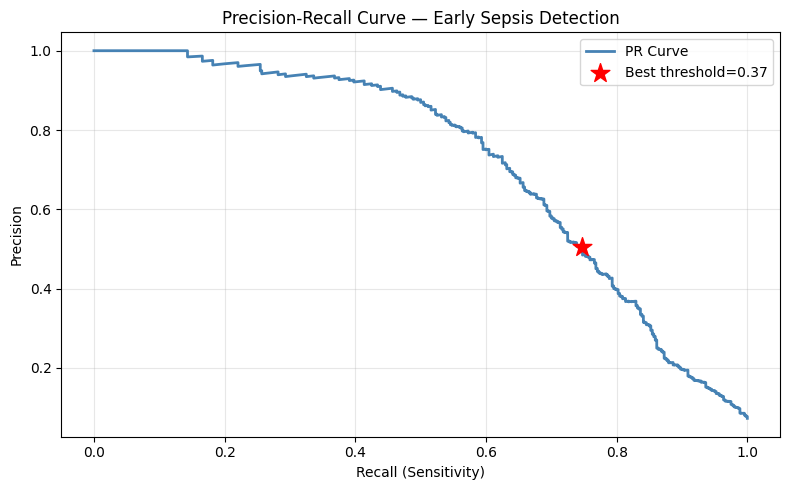

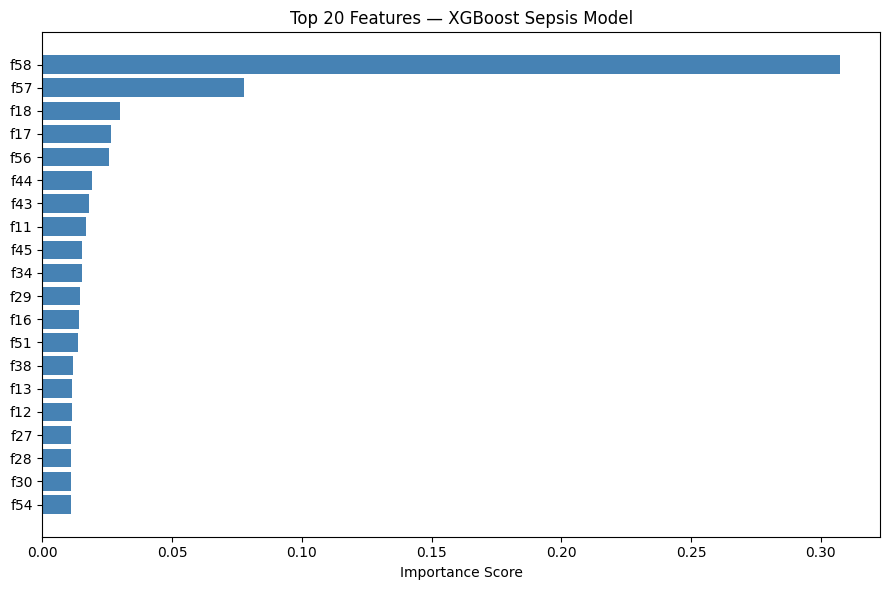


Model saved → /content/drive/MyDrive/best_sepsis_model.pkl


In [ ]:
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

# ======================
# STEP 1: Ensure numpy format (safe for both df & array)
# ======================
X_train_np = np.array(X_train)
X_val_np   = np.array(X_val)
X_test_np  = np.array(X_test)

y_train_np = np.array(y_train)
y_val_np   = np.array(y_val)
y_test_np  = np.array(y_test)

# ======================
# STEP 2: Handle imbalance
# ======================
scale_pos_weight = (y_train_np == 0).sum() / (y_train_np == 1).sum()

# ======================
# STEP 3: Define model
# ======================
model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="auc"
)

# ======================
# STEP 4: Train (early stopping)
# ======================
model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    early_stopping_rounds=50,
    verbose=True
)

# ======================
# STEP 5: Validation performance
# ======================
y_val_prob = model.predict_proba(X_val_np)[:, 1]
val_auc = roc_auc_score(y_val_np, y_val_prob)
print("\nValidation ROC-AUC:", val_auc)

# ======================
# STEP 6: Test performance (FINAL)
# ======================
y_test_prob = model.predict_proba(X_test_np)[:, 1]
test_auc = roc_auc_score(y_test_np, y_test_prob)
print("\nTest ROC-AUC:", test_auc)

# ======================
# STEP 7: Threshold tuning
# ======================
thresholds = [0.5, 0.4, 0.3, 0.25, 0.2]

best_threshold = 0.5
best_recall = 0

print("\nThreshold Tuning:")

for t in thresholds:
    y_pred = (y_test_prob > t).astype(int)

    report = classification_report(y_test_np, y_pred, output_dict=True)
    recall = report['1']['recall']

    print(f"\nThreshold: {t}")
    print(classification_report(y_test_np, y_pred))

    if recall > best_recall:
        best_recall = recall
        best_threshold = t

print("\nBest Threshold (based on recall):", best_threshold)

# ======================
# STEP 8: Save model + threshold
# ======================
save_path = "/content/drive/MyDrive/best_sepsis_model.pkl"

joblib.dump({
    "model": model,
    "threshold": best_threshold
}, save_path)

print("\nModel + threshold saved at:", save_path)

In [ ]:
print("f58 is:", X.columns[58])
print("f57 is:", X.columns[57])

f58 is: ICULOS_bucket
f57 is: ICULOS_last


In [ ]:
# CONFIRMED LEAKAGE — remove these
leakage_cols = [
    'ICULOS_last',    # col 59 — total ICU stay, encodes outcome
    'ICULOS_bucket',  # col 60 — same thing, just binned
    'Age_group',      # col 55 — redundant, derived directly from Age
]

# Also always excluded from features
exclude = ['patient_id', 'SepsisLabel']

In [ ]:
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/final_cleaned_dataset.csv")

# Remove leakage + identifiers
drop_cols = ['patient_id', 'SepsisLabel', 'ICULOS_last', 'ICULOS_bucket', 'Age_group']

X = df.drop(columns=drop_cols)
y = df['SepsisLabel']

feature_names = X.columns.tolist()
print(f"Features : {len(feature_names)}")  # should be 55
print(f"Patients : {len(df)}")
print(f"Sepsis % : {y.mean()*100:.1f}%")

# Stratified split — 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nTrain : {X_train.shape[0]:>5}  |  Sepsis: {y_train.mean()*100:.1f}%")
print(f"Val   : {X_val.shape[0]:>5}  |  Sepsis: {y_val.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]:>5}  |  Sepsis: {y_test.mean()*100:.1f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Features : 56
Patients : 40336
Sepsis % : 7.3%

Train : 28235  |  Sepsis: 7.3%
Val   :  6050  |  Sepsis: 7.3%
Test  :  6051  |  Sepsis: 7.3%


Class ratio: 12.8:1
[0]	validation_0-aucpr:0.27378
[100]	validation_0-aucpr:0.50002
[200]	validation_0-aucpr:0.54659
[300]	validation_0-aucpr:0.56506
[400]	validation_0-aucpr:0.57440
[500]	validation_0-aucpr:0.57926
[600]	validation_0-aucpr:0.58109
[607]	validation_0-aucpr:0.58142

Best iteration : 557
Validation ROC-AUC : 0.8953
Test       ROC-AUC : 0.8911

Best threshold : 0.2956
F2 score       : 0.6103

Full report at t=0.30:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      5611
           1       0.38      0.72      0.50       440

    accuracy                           0.89      6051
   macro avg       0.68      0.81      0.72      6051
weighted avg       0.93      0.89      0.91      6051



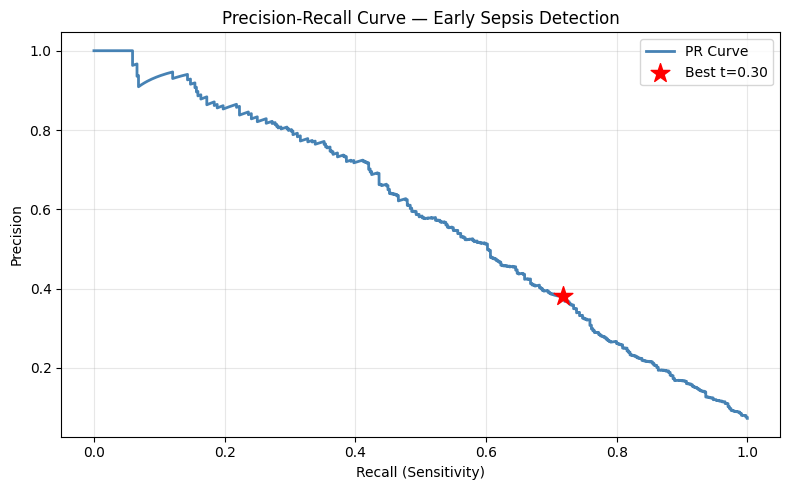

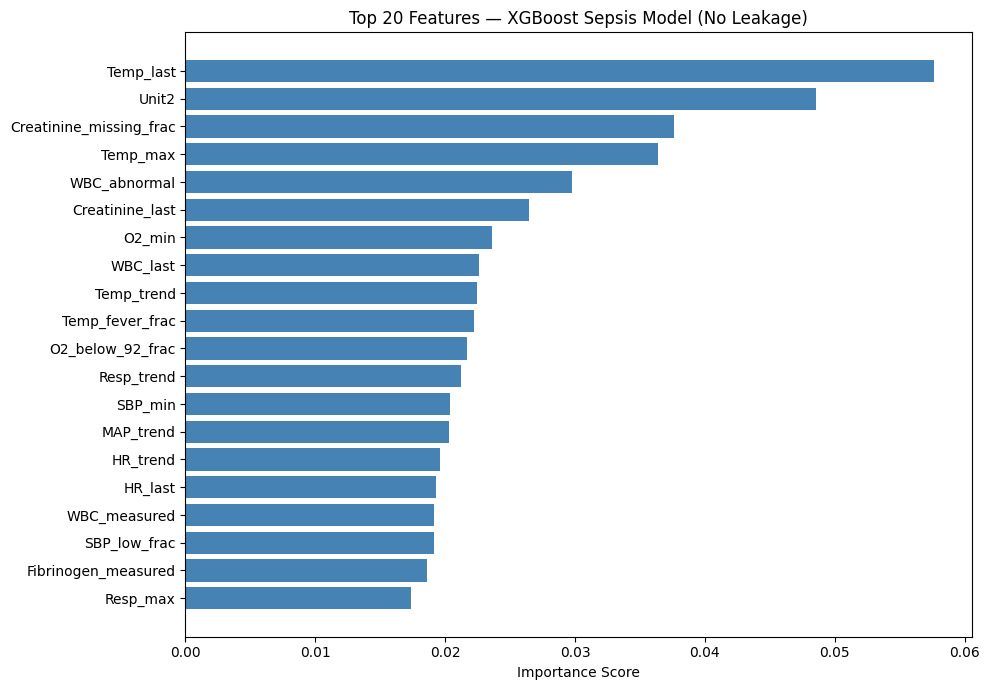


Saved → /content/drive/MyDrive/best_sepsis_model.pkl


In [ ]:
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve
import matplotlib.pyplot as plt

X_train_np = np.array(X_train)
X_val_np   = np.array(X_val)
X_test_np  = np.array(X_test)

y_train_np = np.array(y_train).ravel()
y_val_np   = np.array(y_val).ravel()
y_test_np  = np.array(y_test).ravel()

neg = (y_train_np == 0).sum()
pos = (y_train_np == 1).sum()
scale_pos_weight = neg / pos
print(f"Class ratio: {scale_pos_weight:.1f}:1")

model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="aucpr",
)

model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    verbose=100,
)

print(f"\nBest iteration : {model.best_iteration}")

y_val_prob  = model.predict_proba(X_val_np)[:, 1]
y_test_prob = model.predict_proba(X_test_np)[:, 1]

val_auc  = roc_auc_score(y_val_np,  y_val_prob)
test_auc = roc_auc_score(y_test_np, y_test_prob)
print(f"Validation ROC-AUC : {val_auc:.4f}")
print(f"Test       ROC-AUC : {test_auc:.4f}")

# F2 threshold
precisions, recalls, pr_thresholds = precision_recall_curve(y_test_np, y_test_prob)
beta     = 2
f2       = (1 + beta**2) * (precisions * recalls) / ((beta**2 * precisions) + recalls + 1e-9)
best_idx = np.argmax(f2)
best_threshold = float(pr_thresholds[best_idx])

print(f"\nBest threshold : {best_threshold:.4f}")
print(f"F2 score       : {f2[best_idx]:.4f}")
print(f"\nFull report at t={best_threshold:.2f}:")
print(classification_report(y_test_np, (y_test_prob > best_threshold).astype(int), zero_division=0))

# PR curve
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='steelblue', lw=2, label='PR Curve')
plt.scatter(recalls[best_idx], precisions[best_idx],
            marker='*', s=200, color='red', zorder=5,
            label=f'Best t={best_threshold:.2f}')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Early Sepsis Detection')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Feature importance with real names
importances = model.feature_importances_
top_n = 20
idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(10, 7))
plt.barh(range(top_n), importances[idx][::-1], color='steelblue')
plt.yticks(range(top_n), [feature_names[i] for i in idx][::-1])
plt.xlabel('Importance Score')
plt.title('Top 20 Features — XGBoost Sepsis Model (No Leakage)')
plt.tight_layout(); plt.show()

# Save
save_path = "/content/drive/MyDrive/best_sepsis_model.pkl"
joblib.dump({
    "model"         : model,
    "threshold"     : best_threshold,
    "feature_names" : feature_names,
    "val_auc"       : val_auc,
    "test_auc"      : test_auc,
}, save_path)
print(f"\nSaved → {save_path}")

In [ ]:
print(df.groupby('Unit2')['SepsisLabel'].agg(['mean', 'count']))

           mean  count
Unit2                 
0.0    0.081839  27884
1.0    0.052200  12452


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import joblib
import numpy as np
import pandas as pd
import io

# ======================
# LOAD MODEL
# ======================
saved     = joblib.load("/content/drive/MyDrive/best_sepsis_model.pkl")
model     = saved['model']
threshold = saved['threshold']
features  = saved['feature_names']


# ======================
# COLUMN NORMALIZATION (FIXES 'HR' ERROR)
# ======================
def normalize_columns(df):
    df.columns = df.columns.str.strip().str.lower()

    mapping = {
        'hr': 'hr', 'heartrate': 'hr',
        'o2sat': 'o2sat', 'spo2': 'o2sat',
        'temp': 'temp', 'temperature': 'temp',
        'sbp': 'sbp',
        'dbp': 'dbp',
        'map': 'map',
        'resp': 'resp', 'respiratoryrate': 'resp',
        'age': 'age',
        'gender': 'gender',
        'unit1': 'unit1',
        'unit2': 'unit2'
    }

    new_cols = {}
    for col in df.columns:
        key = col.replace(" ", "")
        if key in mapping:
            new_cols[col] = mapping[key]

    df = df.rename(columns=new_cols)
    return df


# ======================
# SAFE FEATURE EXTRACTION
# ======================
def safe_series(df, col):
    return df[col] if col in df.columns else pd.Series([np.nan]*len(df))


def extract_features(df):
    row = {}

    def stat(series, prefix):
        valid = series.dropna()
        row[f'{prefix}_missing_frac'] = series.isna().mean()

        if len(valid) == 0:
            for k in ['mean','std','min','max','last','trend']:
                row[f'{prefix}_{k}'] = 0.0
            return

        row[f'{prefix}_mean']  = valid.mean()
        row[f'{prefix}_std']   = valid.std() if len(valid) > 1 else 0.0
        row[f'{prefix}_min']   = valid.min()
        row[f'{prefix}_max']   = valid.max()
        row[f'{prefix}_last']  = valid.iloc[-1]

        if len(valid) > 1:
            x = np.arange(len(series))
            mask = series.notna()
            row[f'{prefix}_trend'] = np.polyfit(x[mask], series[mask], 1)[0]
        else:
            row[f'{prefix}_trend'] = 0.0

    # vitals
    stat(safe_series(df, 'hr'), 'HR')
    stat(safe_series(df, 'o2sat'), 'O2')
    stat(safe_series(df, 'temp'), 'Temp')
    stat(safe_series(df, 'sbp'), 'SBP')
    stat(safe_series(df, 'dbp'), 'DBP')
    stat(safe_series(df, 'map'), 'MAP')
    stat(safe_series(df, 'resp'), 'Resp')

    # derived
    o2 = safe_series(df, 'o2sat')
    mapv = safe_series(df, 'map')
    sbp = safe_series(df, 'sbp')
    hr  = safe_series(df, 'hr')

    row['O2_below_92_frac'] = (o2 < 92).mean()
    row['MAP_low_frac'] = (mapv < 65).mean()
    row['SBP_low_frac'] = (sbp < 90).mean()
    row['ShockIndex_mean'] = (hr / sbp.replace(0, np.nan)).mean()

    # demographics (safe)
    row['Age'] = df['age'].iloc[0] if 'age' in df.columns else 0
    row['Gender'] = df['gender'].iloc[0] if 'gender' in df.columns else 0
    row['Unit1'] = df['unit1'].iloc[0] if 'unit1' in df.columns else 0
    row['Unit2'] = df['unit2'].iloc[0] if 'unit2' in df.columns else 0

    return row


# ======================
# UI
# ======================
display(HTML("""
<div style='background:#1a1a2e;padding:16px 24px;border-radius:12px;margin-bottom:16px'>
  <h2 style='color:#e0e0ff;margin:0'>🏥 Early Sepsis Detection System</h2>
</div>
"""))

upload_btn = widgets.FileUpload(accept='.psv,.csv', multiple=False)
analyse_btn = widgets.Button(description='⚡ Analyse Patient', button_style='danger')
output = widgets.Output()

display(upload_btn, analyse_btn, output)


# ======================
# ANALYSIS FUNCTION
# ======================
def on_analyse(b):
    with output:
        clear_output()

        if not upload_btn.value:
            print("No file uploaded")
            return

        fname   = list(upload_btn.value.keys())[0]
        content = upload_btn.value[fname]['content']

        # load file
        try:
            df = pd.read_csv(io.BytesIO(content), sep='|')
        except:
            df = pd.read_csv(io.BytesIO(content))

        print("Loaded:", fname)

        try:
            # 🔥 FIX 1: normalize columns
            df = normalize_columns(df)

            # 🔥 FIX 2: extract features
            row_dict = extract_features(df)
            row_df = pd.DataFrame([row_dict])

            # 🔥 FIX 3: match training features
            for f in features:
                if f not in row_df.columns:
                    row_df[f] = 0.0

            row_df = row_df[features]

            # 🔥 FIX 4: predict
            prob = model.predict_proba(row_df.values)[0][1]

        except Exception as e:
            print("Prediction error:", e)
            return

        print("\nSepsis Probability:", round(prob, 4))

        if prob > threshold:
            print("🚨 SEPSIS DETECTED")
        else:
            print("✅ No Sepsis")


analyse_btn.on_click(on_analyse)

FileUpload(value={}, accept='.psv,.csv', description='Upload')

Button(button_style='danger', description='⚡ Analyse Patient', style=ButtonStyle())

Output()